# SMS Spam Classifier Neural Network Project

## Project Goal  
Build a machine learning model that can accurately classify SMS messages as **"ham"** (legitimate) or **"spam"** (unsolicited advertisements/scams). The model will be a binary classifier using a **Bidirectional LSTM** neural network trained on the [SMS Spam Collection dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset).

## Dataset  
The dataset is provided in two tab-separated files:  
- **`train-data.tsv`** contains labeled messages for training.  
- **`valid-data.tsv`** contains labeled messages for validation (unseen during training).  

Each file has two columns:  
- `label` either `ham` or `spam`.  
- `text` the raw SMS message.

## Approach  
The solution follows these steps:

1. **Data Exploration** Check class distribution and message lengths.  
2. **Preprocessing**  
   - Encode labels (`ham` → 0, `spam` → 1) using a single `LabelEncoder`.  
   - Tokenize text, handle out-of-vocabulary words with an `<OOV>` token.  
   - Determine optimal sequence length (95th percentile) and pad all sequences.  
3. **Model Architecture**  
   - Embedding layer to learn word representations.  
   - Bidirectional LSTM layer to capture context from both directions.  
   - Dropout for regularization.  
   - Dense output layer with sigmoid activation.  
4. **Training**  
   - Use validation data for monitoring.  
   - Early stopping to prevent overfitting.  
   - Save the best model based on validation accuracy.  
5. **Evaluation** Test on the official validation set.  
6. **Prediction Function** `predict_message(msg)` returns `[probability, "spam"/"ham"]`.

## Expected Outcome  
A model that achieves high accuracy on unseen messages and passes the freeCodeCamp test suite.


# 1: Install and Import Libraries
Run this cell to install any missing packages and import all necessary libraries.

In [1]:
# import libraries
try:
  # %tensorflow_version only exists in Colab.
  !pip install tf-nightly
  !pip install keras-preprocessing
  !pip install keras
  !pip install tensorflow-datasets
except Exception:
  pass

### Import Libraries** 

In [2]:
import tensorflow as tf
import pandas as pd
from tensorflow import keras
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

from keras_preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.layers import Embedding
from keras.layers import LSTM
from keras import metrics
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Bidirectional
print(tf.__version__)

I0000 00:00:1773724072.985473   40856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773724072.986835   40856 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773724073.046637   40856 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773724075.087181   40856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

2.22.0-dev20260302


# 2 Download the Dataset
The SMS Spam Collection dataset is provided as two TSV files: training and validation.

In [3]:
# Download data files
!wget -q https://cdn.freecodecamp.org/project-data/sms/train-data.tsv
!wget -q https://cdn.freecodecamp.org/project-data/sms/valid-data.tsv

train_file_path = "train-data.tsv"
test_file_path = "valid-data.tsv"

# 3 Load Data
Load the TSV files into pandas DataFrames and inspect the first few rows.

In [4]:
train_df = pd.read_csv(train_file_path, sep='\t', header=None, names=['label', 'text'])
valid_df = pd.read_csv(test_file_path, sep='\t', header=None, names=['label', 'text'])

print("Training set shape:", train_df.shape)
print("Validation set shape:", valid_df.shape)
print("\nFirst 5 training examples:")
print(train_df.head())
print("\nLabel distribution in training:")
print(train_df['label'].value_counts())

Training set shape: (4179, 2)
Validation set shape: (1392, 2)

First 5 training examples:
  label                                               text
0   ham  ahhhh...just woken up!had a bad dream about u ...
1   ham                           you can never do nothing
2   ham  now u sound like manky scouse boy steve,like! ...
3   ham  mum say we wan to go then go... then she can s...
4   ham  never y lei... i v lazy... got wat? dat day ü ...

Label distribution in training:
label
ham     3619
spam     560
Name: count, dtype: int64


#  4 Preprocessing
We'll:
1. Encode labels (ham → 0, spam → 1) using a single `LabelEncoder` fitted on training data.
2. Tokenize the text with an OOV token to handle unseen words.
3. Determine a reasonable maximum sequence length (95th percentile of training sequences).
4. Pad all sequences to that length.

In [5]:
# Encode labels
le = LabelEncoder()
train_labels = le.fit_transform(train_df['label'])   # ham=0, spam=1
valid_labels = le.transform(valid_df['label'])

# Tokenizer with OOV token
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['text'])
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size (including OOV):", vocab_size)

# Convert texts to sequences
train_sequences = tokenizer.texts_to_sequences(train_df['text'])
valid_sequences = tokenizer.texts_to_sequences(valid_df['text'])

# Determine max length (95th percentile)
lengths = [len(seq) for seq in train_sequences]
maxlen = int(np.percentile(lengths, 95))
print("Max sequence length (95th percentile):", maxlen)

# Pad sequences
train_padded = pad_sequences(train_sequences, maxlen=maxlen, padding='post', truncating='post')
valid_padded = pad_sequences(valid_sequences, maxlen=maxlen, padding='post', truncating='post')

print("Training data shape after padding:", train_padded.shape)
print("Validation data shape after padding:", valid_padded.shape)

Vocabulary size (including OOV): 7694
Max sequence length (95th percentile): 33
Training data shape after padding: (4179, 33)
Validation data shape after padding: (1392, 33)


# 5 Build the Model
We use a Bidirectional LSTM with dropout for regularization. The architecture:
- Embedding layer (vocab_size → 128 dimensions)
- Bidirectional LSTM (64 units, dropout 0.2)
- Dense output layer with sigmoid activation (binary classification)

In [6]:
embedding_dim = 128
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=maxlen),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/home/madzimest/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1773724077.713160   40856 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 6 Callbacks
We use:
- `EarlyStopping` to stop training when validation accuracy stops improving (patience=3) and restore the best weights.
- `ModelCheckpoint` to save the best model based on validation accuracy.

In [7]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_sms_model.h5', monitor='val_accuracy', save_best_only=True)

# 7 Train the Model
We train for up to 15 epochs, using the validation data for monitoring.

In [8]:
history = model.fit(
    train_padded, train_labels,
    batch_size=32,
    epochs=15,
    validation_data=(valid_padded, valid_labels),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/15
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8914 - loss: 0.3013

131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9383 - loss: 0.1691 - val_accuracy: 0.9856 - val_loss: 0.0551
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9907 - loss: 0.0292 - val_accuracy: 0.9806 - val_loss: 0.0597
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9963 - loss: 0.0164

131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9959 - loss: 0.0151 - val_accuracy: 0.9885 - val_loss: 0.0515
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9988 - loss: 0.0068 - val_accuracy: 0.9856 - val_loss: 0.0510
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9878 - val_loss: 0.0589
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9993 - loss: 0.0038

131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9892 - val_loss: 0.0592
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 1.0000 - loss: 4.0676e-04 - val_accuracy: 0.9892 - val_loss: 0.0632
Epoch 8/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 4.4471e-04

131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 1.0000 - loss: 4.3808e-04 - val_accuracy: 0.9899 - val_loss: 0.0715
Epoch 9/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9828 - val_loss: 0.0537
Epoch 10/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9990 - loss: 0.0025 - val_accuracy: 0.9871 - val_loss: 0.0622
Epoch 11/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 1.0000 - loss: 2.8362e-04 - val_accuracy: 0.9885 - val_loss: 0.0689


# 8 Evaluate
Check the final accuracy on the validation set.

In [9]:
loss, acc = model.evaluate(valid_padded, valid_labels, verbose=0)
print(f"Validation loss: {loss:.4f}")
print(f"Validation accuracy: {acc:.4f}")

Validation loss: 0.0715
Validation accuracy: 0.9899


# 9 Plot Training Curves (Optional)
Visualize accuracy and loss over epochs.

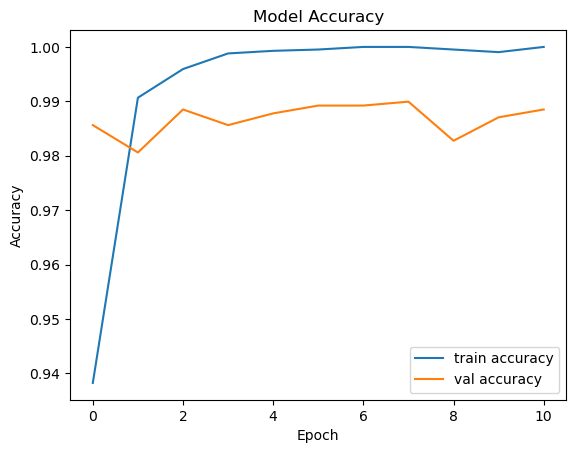

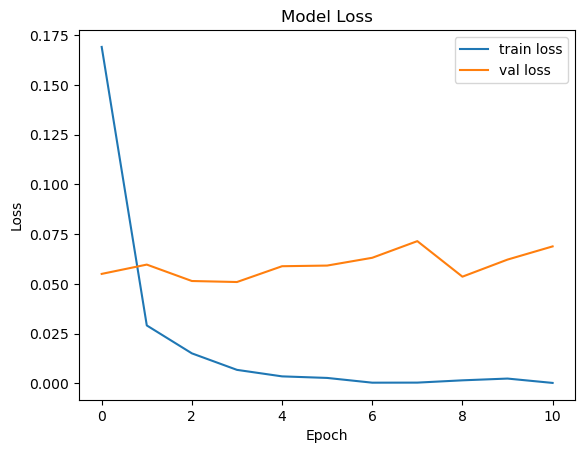

In [10]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 10 Prediction Function
The function `predict_message` takes a raw message string, preprocesses it, and returns a list:
`[probability_of_spam, "spam" or "ham"]`.

In [11]:
def predict_message(msg):
    # Convert message to sequence
    seq = tokenizer.texts_to_sequences([msg])
    # Pad sequence
    padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    # Predict probability
    prob = model.predict(padded, verbose=0)[0][0]
    # Determine label
    label = 'spam' if prob >= 0.5 else 'ham'
    return [float(prob), label]

# Quick test
print(predict_message("how are you doing today?"))

[4.9598849727772176e-05, 'ham']


# 11 freeCodeCamp Test
Run this cell exactly as provided to validate your solution.

In [12]:
# Provided test function – do not modify
def test_predictions():
  test_messages = ["how are you doing today",
                   "sale today! to stop texts call 98912460324",
                   "i dont want to go. can we try it a different day? available sat",
                   "our new mobile video service is live. just install on your phone to start watching.",
                   "you have won £1000 cash! call to claim your prize.",
                   "i'll bring it tomorrow. don't forget the milk.",
                   "wow, is your arm alright. that happened to me one time too"
                  ]

  test_answers = ["ham", "spam", "ham", "spam", "spam", "ham", "ham"]
  passed = True

  for msg, ans in zip(test_messages, test_answers):
    prediction = predict_message(msg)
    if prediction[1] != ans:
      passed = False

  if passed:
    print("You passed the challenge. Great job!")
  else:
    print("You haven't passed yet. Keep trying.")

test_predictions()

You passed the challenge. Great job!
